# 더블레이어 IPM 55–90° CCF + DNN 최적설계 분석

이 노트북의 목적은 50개 설계점 자체에서 최적점을 고르는 것이 아니다.

1. 신규 55–90° CCF 50점과 기존 70–90° CCF 50점을 결합
2. 총 100개 FEMM 결과로 DNN surrogate 학습
3. 55–90° 전체 범위에서 형상검사 통과 후보 10,000점 예측
4. 다음 세 파레토를 계산
   - 평균토크 최대–절대 리플 최소
   - 평균토크 최대–자석 사용량 최소
   - 평균토크 최대–리플 최소–자석 사용량 최소
5. 싱글레이어 FEMM 결과와 비교하고 재검증 후보 선정

> DNN 후보의 출력은 FEMM 해석값이 아니므로 최종 후보는 다시 FEMM으로 검증해야 한다.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from IPython.display import display
from scipy.stats import qmc
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import generate_v_ipm_motor as motor_base
from generate_double_layer_ccf_50 import RANGES as BASE_RANGES, evaluate

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Glyph .* missing")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5.5)
pd.options.display.float_format = "{:.4f}".format
pio.renderers.default = "notebook_connected"

ROOT = Path.cwd()
if not (ROOT / "double_layer_ccf_55to90_50_results").exists():
    ROOT = Path("C:/Users/139/Documents/pyFEMM 2")

NEW_DIR = ROOT / "double_layer_ccf_55to90_50_results"
OLD_DIR = ROOT / "double_layer_ccf_50_results"
SINGLE_DIR = ROOT / "doe_axis_shortedge_results"

new50 = pd.read_csv(NEW_DIR / "double_layer_ccf_summary.csv")
old50 = pd.read_csv(OLD_DIR / "double_layer_ccf_summary.csv")
single50 = pd.read_csv(SINGLE_DIR / "axis_shortedge_ccf_summary.csv")
new50["dataset"] = "New CCF 55–90°"
old50["dataset"] = "Old CCF 70–90°"
data = pd.concat([new50, old50], ignore_index=True)

factors = [
    "total_thickness_mm", "inner_length_mm",
    "v_angle_deg", "layer_normal_gap_mm",
]
factor_labels = ["Total thickness", "Inner length", "V angle", "Layer gap"]
mean_col = "loaded_torque_mean_Nm"
ripple_col = "loaded_torque_pkpk_Nm"
targets = [mean_col, ripple_col]

RANGES = dict(BASE_RANGES)
RANGES["v_angle_deg"] = (55.0, 90.0)
print("FEMM training samples:", len(data))
print(data.dataset.value_counts())

FEMM training samples: 100
dataset
New CCF 55–90°    50
Old CCF 70–90°    50
Name: count, dtype: int64


## 1. FEMM 데이터 완전성 및 범위

In [2]:
checks = []
for label, frame, directory in [
    ("55–90°", new50, NEW_DIR), ("70–90°", old50, OLD_DIR)
]:
    for run in frame.run.astype(int):
        path = directory / f"run_{run:03d}" / "axis_shortedge_loaded_sweep.csv"
        n = len(pd.read_csv(path)) if path.exists() else 0
        checks.append((label, run, n, "OK" if n == 15 else "CHECK"))
checks = pd.DataFrame(checks, columns=["dataset", "run", "points", "status"])
display(checks.groupby(["dataset", "status"]).size().to_frame("designs"))
assert len(data) == 100 and (checks.points == 15).all()
display(data[factors + targets].describe().T)

,,designs
dataset,status,
55–90°,OK,50
70–90°,OK,50


,count,mean,std,min,25%,50%,75%,max
total_thickness_mm,100.0000,4.4467,0.6018,3.5099,3.9118,4.4122,4.9203,5.4904
inner_length_mm,100.0000,15.6459,0.6176,14.5011,15.1563,15.7154,16.1162,16.7442
v_angle_deg,100.0000,76.2255,8.7597,55.2840,71.0035,76.1113,83.6610,89.7585
layer_normal_gap_mm,100.0000,1.2455,0.4422,0.5112,0.9010,1.2463,1.6273,1.9804
loaded_torque_mean_Nm,100.0000,42.6742,3.9551,34.3023,39.6799,42.4330,45.0257,51.7571
loaded_torque_pkpk_Nm,100.0000,6.8519,2.3261,3.0549,4.7861,7.0182,8.2528,12.9487


## 2. 실제 FEMM 100점의 분포

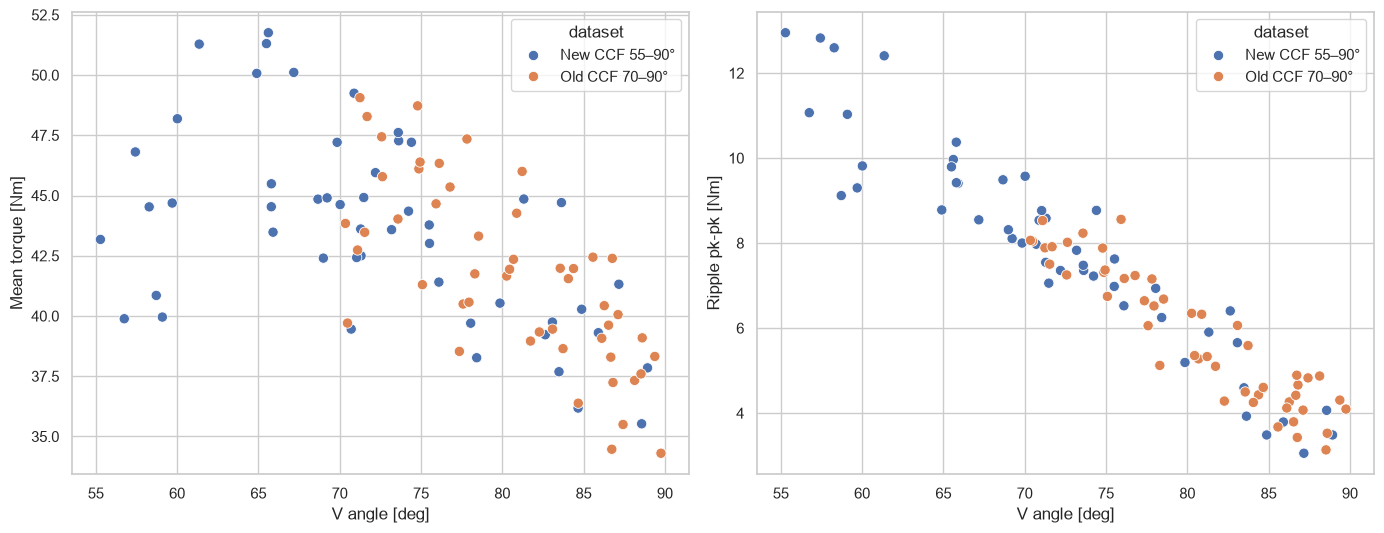

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(
    data=data, x="v_angle_deg", y=mean_col,
    hue="dataset", ax=axes[0], s=55,
)
sns.scatterplot(
    data=data, x="v_angle_deg", y=ripple_col,
    hue="dataset", ax=axes[1], s=55,
)
axes[0].set(xlabel="V angle [deg]", ylabel="Mean torque [Nm]")
axes[1].set(xlabel="V angle [deg]", ylabel="Ripple pk-pk [Nm]")
plt.tight_layout()
plt.show()

## 3. DNN surrogate 반복 교차검증

,Repeated-CV R2,Repeated-CV RMSE
Mean torque [Nm],0.9813,0.5383
Ripple pk-pk [Nm],0.9636,0.4414


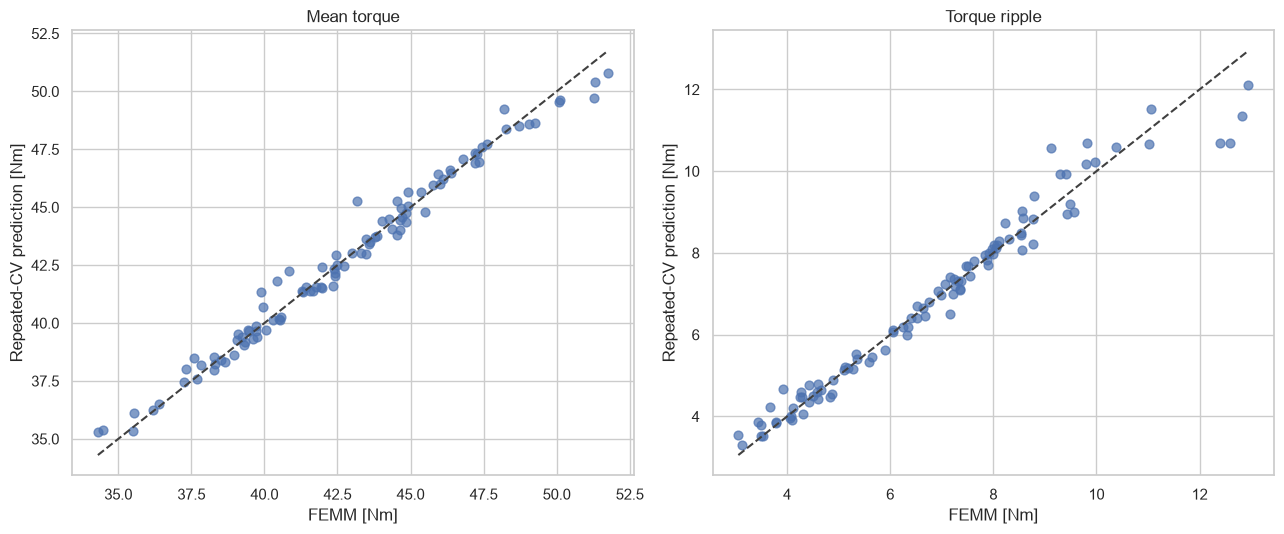

In [4]:
X = data[factors].to_numpy(dtype=float)
y = data[targets].to_numpy(dtype=float)

def make_dnn(seed):
    network = Pipeline([
        ("scale_x", StandardScaler()),
        ("dnn", MLPRegressor(
            hidden_layer_sizes=(48, 24, 12),
            activation="tanh",
            solver="lbfgs",
            alpha=1.0,
            max_iter=5000,
            random_state=seed,
        )),
    ])
    return TransformedTargetRegressor(
        regressor=network, transformer=StandardScaler()
    )

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=20260803)
pred_sum = np.zeros_like(y)
pred_count = np.zeros(len(y), dtype=int)
for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    model = make_dnn(1000 + fold)
    model.fit(X[train_idx], y[train_idx])
    pred_sum[test_idx] += model.predict(X[test_idx])
    pred_count[test_idx] += 1
cv_pred = pred_sum / pred_count[:, None]

cv_metrics = pd.DataFrame({
    "Repeated-CV R2": [
        r2_score(y[:, j], cv_pred[:, j]) for j in range(2)
    ],
    "Repeated-CV RMSE": [
        root_mean_squared_error(y[:, j], cv_pred[:, j])
        for j in range(2)
    ],
}, index=["Mean torque [Nm]", "Ripple pk-pk [Nm]"])
display(cv_metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for j, title in enumerate(["Mean torque", "Torque ripple"]):
    axes[j].scatter(y[:, j], cv_pred[:, j], s=40, alpha=0.7)
    lo = min(y[:, j].min(), cv_pred[:, j].min())
    hi = max(y[:, j].max(), cv_pred[:, j].max())
    axes[j].plot([lo, hi], [lo, hi], "--", color="0.25")
    axes[j].set(
        xlabel="FEMM [Nm]", ylabel="Repeated-CV prediction [Nm]",
        title=title,
    )
plt.tight_layout()
plt.show()

## 4. 55–90° 형상검사 통과 LHS 후보 10,000점

In [5]:
cache = ROOT / "double_layer_55to90_dnn_candidates_10000.csv"
n_candidates = 10_000
if cache.exists() and len(pd.read_csv(cache)) == n_candidates:
    candidates = pd.read_csv(cache)
    print(f"Loaded {len(candidates):,} cached candidates")
else:
    names = list(RANGES)
    lower = np.array([RANGES[name][0] for name in names])
    upper = np.array([RANGES[name][1] for name in names])
    sampler = qmc.LatinHypercube(d=4, seed=20260803)
    valid = []
    tested = 0
    while len(valid) < n_candidates:
        batch = qmc.scale(sampler.random(12_000), lower, upper)
        for values in batch:
            tested += 1
            row = evaluate(
                tested,
                {name: float(value) for name, value in zip(names, values)},
            )
            if row["geometry_status"] == "OK":
                valid.append(row)
                if len(valid) == n_candidates:
                    break
    candidates = pd.DataFrame(valid)
    candidates["candidate"] = np.arange(1, len(candidates) + 1)
    print(f"Tested {tested:,}; accepted {len(candidates):,}")
display(candidates[factors + [
    "outer_bridge_min_mm", "shaft_clearance_min_mm",
    "other_magnet_gap_min_mm"
]].describe().T)

Loaded 10,000 cached candidates


,count,mean,std,min,25%,50%,75%,max
total_thickness_mm,10000.0000,4.4895,0.5780,3.5003,3.9852,4.4838,4.9876,5.4999
inner_length_mm,10000.0000,15.6341,0.6561,14.5001,15.0684,15.6314,16.1956,16.7997
v_angle_deg,10000.0000,72.2031,9.9370,55.0005,63.6734,72.1712,80.7510,89.9998
layer_normal_gap_mm,10000.0000,1.2474,0.4326,0.5001,0.8728,1.2464,1.6211,2.0000
outer_bridge_min_mm,10000.0000,3.9277,0.6688,2.1926,3.4145,3.9020,4.4292,5.9013
shaft_clearance_min_mm,10000.0000,6.9940,1.1338,4.1372,6.1023,6.9571,7.8789,9.9027
other_magnet_gap_min_mm,10000.0000,0.6073,0.0041,0.5019,0.6075,0.6075,0.6075,0.6075


## 5. DNN 30개 앙상블 예측과 총 불확실성

In [6]:
candidate_X = candidates[factors].to_numpy(dtype=float)
ensemble = []
for seed in range(30):
    model = make_dnn(2000 + seed)
    model.fit(X, y)
    ensemble.append(model.predict(candidate_X))
ensemble = np.stack(ensemble)
pred = ensemble.mean(axis=0)
ensemble_std = ensemble.std(axis=0, ddof=1)
cv_rmse = cv_metrics["Repeated-CV RMSE"].to_numpy(dtype=float)
total_unc = np.sqrt(ensemble_std**2 + cv_rmse[None, :]**2)

candidates["pred_mean_torque_Nm"] = pred[:, 0]
candidates["pred_ripple_pkpk_Nm"] = pred[:, 1]
candidates["unc_mean_torque_Nm"] = total_unc[:, 0]
candidates["unc_ripple_pkpk_Nm"] = total_unc[:, 1]
candidates["conservative_mean_Nm"] = pred[:, 0] - total_unc[:, 0]
candidates["conservative_ripple_Nm"] = pred[:, 1] + total_unc[:, 1]

MAGNET_FACTOR = 8 * (0.5 + 0.5 * 0.8 * 0.8)
candidates["magnet_area_total_mm2"] = (
    MAGNET_FACTOR
    * candidates.total_thickness_mm
    * candidates.inner_length_mm
)
candidates["magnet_volume_total_cm3"] = (
    candidates.magnet_area_total_mm2 * motor_base.DEPTH / 1000
)
candidates["torque_per_magnet_Nm_cm3"] = (
    candidates.pred_mean_torque_Nm
    / candidates.magnet_volume_total_cm3
)

## 6. 평균토크 최대–절대 리플 최소 파레토

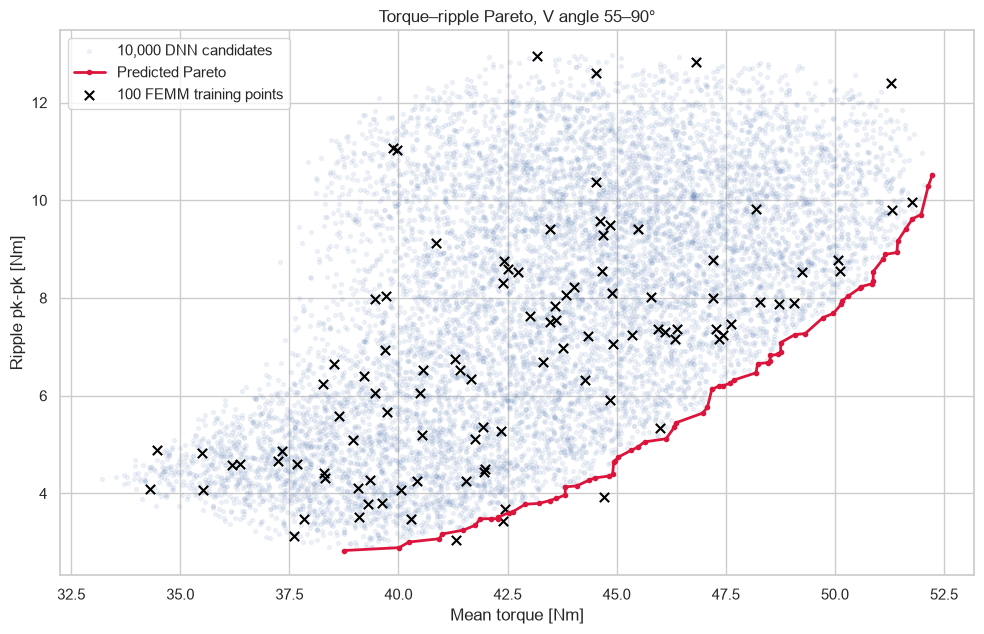

In [7]:
def fast_pareto_2d(frame, maximize, minimize):
    ordered = frame.sort_values(
        [maximize, minimize], ascending=[False, True]
    )
    best = np.inf
    selected = []
    for idx, row in ordered.iterrows():
        if row[minimize] < best:
            selected.append(idx)
            best = row[minimize]
    mask = pd.Series(False, index=frame.index)
    mask.loc[selected] = True
    return mask

candidates["torque_ripple_pareto"] = fast_pareto_2d(
    candidates, "pred_mean_torque_Nm", "pred_ripple_pkpk_Nm"
)
tr_front = candidates[candidates.torque_ripple_pareto].copy()
tr_front = tr_front.sort_values("pred_mean_torque_Nm")

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(
    candidates.pred_mean_torque_Nm,
    candidates.pred_ripple_pkpk_Nm,
    s=8, alpha=0.08, label="10,000 DNN candidates",
)
ax.plot(
    tr_front.pred_mean_torque_Nm, tr_front.pred_ripple_pkpk_Nm,
    "-o", color="crimson", lw=2, ms=3, label="Predicted Pareto",
)
ax.scatter(data[mean_col], data[ripple_col], marker="x", color="black",
           s=45, label="100 FEMM training points")
ax.set(xlabel="Mean torque [Nm]", ylabel="Ripple pk-pk [Nm]",
       title="Torque–ripple Pareto, V angle 55–90°")
ax.legend()
plt.tight_layout()
plt.show()

## 7. 자석 사용량 최소–평균토크 최대 파레토

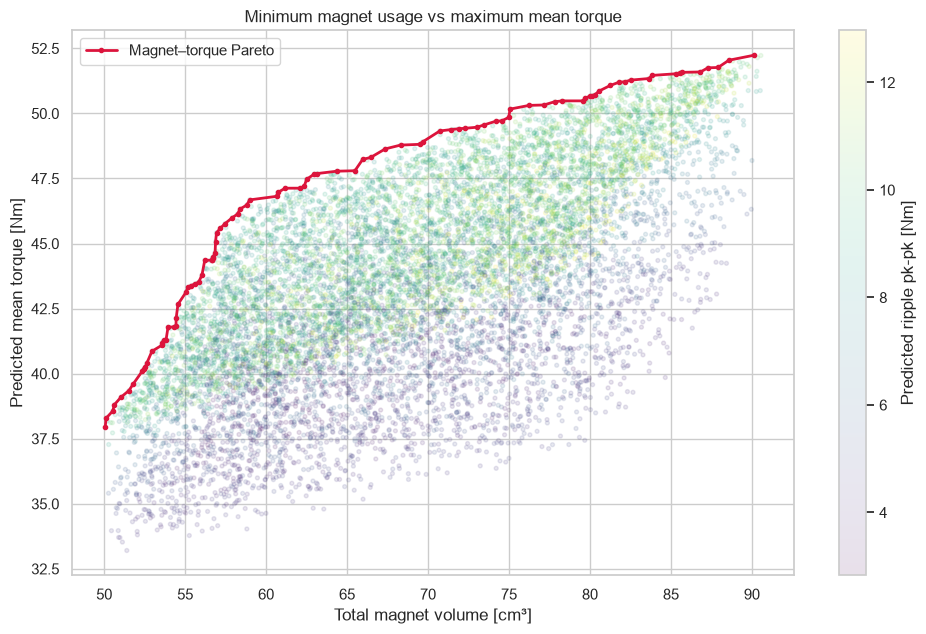

In [8]:
candidates["magnet_torque_pareto"] = fast_pareto_2d(
    candidates, "pred_mean_torque_Nm", "magnet_volume_total_cm3"
)
mt_front = candidates[candidates.magnet_torque_pareto].copy()
mt_front = mt_front.sort_values("magnet_volume_total_cm3")

fig, ax = plt.subplots(figsize=(10, 6.5))
sc = ax.scatter(
    candidates.magnet_volume_total_cm3,
    candidates.pred_mean_torque_Nm,
    c=candidates.pred_ripple_pkpk_Nm,
    cmap="viridis", s=8, alpha=0.12,
)
ax.plot(
    mt_front.magnet_volume_total_cm3, mt_front.pred_mean_torque_Nm,
    "-o", color="crimson", lw=2, ms=3, label="Magnet–torque Pareto",
)
ax.set(xlabel="Total magnet volume [cm³]",
       ylabel="Predicted mean torque [Nm]",
       title="Minimum magnet usage vs maximum mean torque")
fig.colorbar(sc, ax=ax, label="Predicted ripple pk-pk [Nm]")
ax.legend()
plt.tight_layout()
plt.show()

## 8. 토크–리플–자석량 3목적 파레토

In [9]:
mean = candidates.pred_mean_torque_Nm.to_numpy()
ripple = candidates.pred_ripple_pkpk_Nm.to_numpy()
volume = candidates.magnet_volume_total_cm3.to_numpy()
keep = np.ones(len(candidates), dtype=bool)
for i in range(len(candidates)):
    dominated = (
        (mean >= mean[i])
        & (ripple <= ripple[i])
        & (volume <= volume[i])
        & (
            (mean > mean[i])
            | (ripple < ripple[i])
            | (volume < volume[i])
        )
    )
    keep[i] = not dominated.any()
candidates["three_objective_pareto"] = keep
front3 = candidates[candidates.three_objective_pareto].copy()
print("3-objective Pareto designs:", len(front3))

fig = px.scatter_3d(
    front3,
    x="magnet_volume_total_cm3",
    y="pred_ripple_pkpk_Nm",
    z="pred_mean_torque_Nm",
    color="v_angle_deg",
    color_continuous_scale="Plasma",
    hover_name="candidate",
    hover_data={
        "total_thickness_mm": ":.4f",
        "inner_length_mm": ":.4f",
        "v_angle_deg": ":.3f",
        "layer_normal_gap_mm": ":.4f",
        "unc_mean_torque_Nm": ":.3f",
        "unc_ripple_pkpk_Nm": ":.3f",
        "outer_bridge_min_mm": ":.3f",
        "other_magnet_gap_min_mm": ":.3f",
    },
    labels={
        "magnet_volume_total_cm3": "Magnet volume [cm³]",
        "pred_ripple_pkpk_Nm": "Ripple pk-pk [Nm]",
        "pred_mean_torque_Nm": "Mean torque [Nm]",
        "v_angle_deg": "V angle [deg]",
    },
    title="Interactive three-objective predicted Pareto",
)
fig.update_traces(marker={"size": 4, "opacity": 0.8})
fig.update_layout(
    height=720,
    scene={
        "xaxis_title": "Magnet volume [cm³]",
        "yaxis_title": "Ripple pk-pk [Nm]",
        "zaxis_title": "Mean torque [Nm]",
        "dragmode": "orbit",
    },
)
fig.show()

3-objective Pareto designs: 747


## 9. 싱글레이어 대비 비교

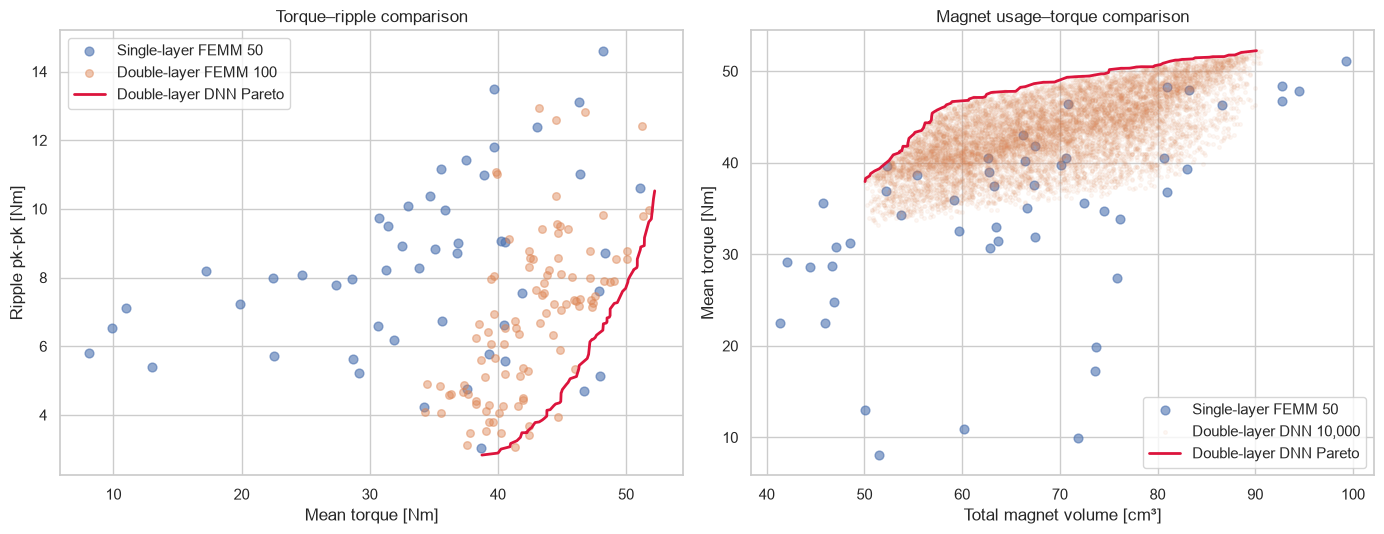

In [10]:
single50["magnet_volume_total_cm3"] = (
    8
    * single50.magnet_thickness_mm
    * single50.magnet_length_mm
    * motor_base.DEPTH / 1000
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(
    single50[mean_col], single50[ripple_col],
    s=40, alpha=0.6, label="Single-layer FEMM 50",
)
axes[0].scatter(
    data[mean_col], data[ripple_col],
    s=30, alpha=0.45, label="Double-layer FEMM 100",
)
axes[0].plot(
    tr_front.pred_mean_torque_Nm, tr_front.pred_ripple_pkpk_Nm,
    color="crimson", lw=2, label="Double-layer DNN Pareto",
)
axes[0].set(xlabel="Mean torque [Nm]", ylabel="Ripple pk-pk [Nm]",
            title="Torque–ripple comparison")
axes[0].legend()

axes[1].scatter(
    single50.magnet_volume_total_cm3, single50[mean_col],
    s=40, alpha=0.6, label="Single-layer FEMM 50",
)
axes[1].scatter(
    candidates.magnet_volume_total_cm3,
    candidates.pred_mean_torque_Nm,
    s=7, alpha=0.06, label="Double-layer DNN 10,000",
)
axes[1].plot(
    mt_front.magnet_volume_total_cm3, mt_front.pred_mean_torque_Nm,
    color="crimson", lw=2, label="Double-layer DNN Pareto",
)
axes[1].set(xlabel="Total magnet volume [cm³]",
            ylabel="Mean torque [Nm]",
            title="Magnet usage–torque comparison")
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. FEMM 재검증 후보 선정

In [11]:
def add_knee_distance(front, x, y, maximize_y=True):
    result = front.copy()
    xspan = result[x].max() - result[x].min()
    yspan = result[y].max() - result[y].min()
    result["x_loss"] = (result[x] - result[x].min()) / xspan
    if maximize_y:
        result["y_loss"] = (result[y].max() - result[y]) / yspan
    else:
        result["y_loss"] = (result[y] - result[y].min()) / yspan
    result["ideal_distance"] = np.hypot(result.x_loss, result.y_loss)
    return result

tr_ranked = add_knee_distance(
    tr_front, "pred_ripple_pkpk_Nm", "pred_mean_torque_Nm", True
)
mt_ranked = add_knee_distance(
    mt_front, "magnet_volume_total_cm3", "pred_mean_torque_Nm", True
)

validation = pd.concat([
    tr_ranked.nsmallest(3, "ideal_distance"),
    mt_ranked.nsmallest(3, "ideal_distance"),
    tr_front.nsmallest(1, "pred_ripple_pkpk_Nm"),
    tr_front.nlargest(1, "pred_mean_torque_Nm"),
]).drop_duplicates("candidate")

validation_cols = [
    "candidate", *factors, "magnet_center_offset_deg",
    "magnet_volume_total_cm3",
    "pred_mean_torque_Nm", "unc_mean_torque_Nm",
    "pred_ripple_pkpk_Nm", "unc_ripple_pkpk_Nm",
    "torque_per_magnet_Nm_cm3",
    "outer_bridge_min_mm", "other_magnet_gap_min_mm",
]
display(validation[validation_cols].set_index("candidate"))

,total_thickness_mm,inner_length_mm,v_angle_deg,layer_normal_gap_mm,magnet_center_offset_deg,magnet_volume_total_cm3,pred_mean_torque_Nm,unc_mean_torque_Nm,pred_ripple_pkpk_Nm,unc_ripple_pkpk_Nm,torque_per_magnet_Nm_cm3,outer_bridge_min_mm,other_magnet_gap_min_mm
candidate,,,,,,,,,,,,,
5983,5.3604,16.7764,79.5556,0.7305,23.7119,88.4884,46.9719,0.5441,5.6440,0.4440,0.5308,3.8520,0.6075
4791,5.2731,16.7742,79.4449,1.2442,23.5585,87.0364,47.0792,0.5448,5.7637,0.4432,0.5409,3.6898,0.6075
7775,5.4471,16.7346,81.5044,0.6316,23.9796,89.6966,46.1324,0.5430,5.1184,0.4440,0.5143,4.0021,0.6075
4325,3.5847,16.7213,66.3079,1.5486,20.8265,58.9821,46.6773,0.5444,8.2399,0.4427,0.7914,3.4102,0.6075
8481,3.7105,16.7561,62.9516,1.5053,19.9701,61.1789,47.1268,0.5448,9.0887,0.4440,0.7703,3.2107,0.6075
9790,3.8173,16.7632,64.5687,1.2607,20.5400,62.9668,47.6666,0.5435,9.0670,0.4430,0.7570,3.3209,0.6075
9439,3.5871,16.6680,88.8637,1.2629,24.8218,58.8335,38.7526,0.5444,2.8311,0.4437,0.6587,4.8946,0.5346
6038,5.4550,16.7909,62.9898,1.2382,20.1571,90.1294,52.2369,0.5483,10.5250,0.4440,0.5796,2.7109,0.6075


## 11. 결과 저장

In [12]:
candidates.to_csv(
    ROOT / "double_layer_55to90_dnn_candidates_10000.csv", index=False
)
tr_front.to_csv(
    ROOT / "double_layer_55to90_torque_ripple_pareto.csv", index=False
)
mt_front.to_csv(
    ROOT / "double_layer_55to90_magnet_torque_pareto.csv", index=False
)
front3.to_csv(
    ROOT / "double_layer_55to90_three_objective_pareto.csv", index=False
)
validation[validation_cols].to_csv(
    ROOT / "double_layer_55to90_femm_validation_candidates.csv", index=False
)
print("Saved DNN candidates, Pareto fronts, and FEMM validation candidates")

Saved DNN candidates, Pareto fronts, and FEMM validation candidates


## 12. 최종 판단 방법

- DNN 파레토는 최적점 후보를 찾는 도구이며 최종 FEMM 결과가 아니다.
- 재검증 후보는 0–30°, 0.5° 간격으로 다시 계산한다.
- 후보별 commutation offset 30–40°를 재탐색한다.
- 싱글레이어와 비교할 때는 동일 전류뿐 아니라 자석 체적, 토크리플, 코깅토크,
  역기전력 THD, 반경력과 약계자 성능을 함께 평가해야 한다.

# 13. 결과 평가와 실제 FEMM 검증 후보

V각 범위를 55°까지 확장하자 최적점이 55° 경계로 내려가지 않고 목적에 따라 내부 영역으로 분리됐다.

- 최대토크 영역: 약 63°
- 자석량 대비 토크 영역: 약 63–69°
- 토크–리플 균형 영역: 약 79–82°
- 리플 최소 영역: 약 87–89°

따라서 기존 70–90° DOE에서 후보가 70° 하한에 몰린 것은 실제 최적각이 70°라서가 아니라 설계범위가 좁았기 때문이다.
GitHub의 기존 싱글레이어 분석에서 나타난 60° 부근 최적 경향과 이번 더블레이어 최대토크 영역이 연결된다.

## 싱글레이어 대비 평가

- Candidate 6038은 싱글레이어 최대토크 Run 27보다 자석을 약 9% 적게 사용하면서 평균토크가 약 2% 높을 것으로 예측됐다. 리플은 비슷하다.
- Candidate 4325는 싱글레이어 Run 49와 비슷한 평균토크를 예측하면서 자석 사용량을 약 36% 줄이지만 리플이 크다.
- Candidate 5983과 4791은 자석을 약 5–6% 줄이고 평균토크를 유지하지만 싱글레이어 Run 49보다 리플이 약 1 Nm 크다.
- Candidate 9439는 싱글레이어 저리플 Run 14와 성능이 비슷해 더블레이어의 명확한 우위는 아직 확인되지 않았다.

## 실제 FEMM 검증 대상

| 우선순위 | Candidate | 목적 | DNN 예측 평균토크 | DNN 예측 리플 |
|---:|---:|---|---:|---:|
| 1 | 6038 | 최대토크 | 52.24 Nm | 10.53 Nm |
| 2 | 4325 | 자석 절감·토크 효율 | 46.68 Nm | 8.24 Nm |
| 3 | 5983 | 토크–리플 균형 | 46.97 Nm | 5.64 Nm |
| 4 | 4791 | 균형 대안 | 47.08 Nm | 5.76 Nm |
| 5 | 9439 | 리플 최소 | 38.75 Nm | 2.83 Nm |

이 다섯 점은 우선 DNN 학습 데이터와 동일한 `0–28° / 2°`, 전류 10 A, commutation offset 35° 조건으로 FEMM 검증한다.
검증 오차가 허용 범위이면 유망 후보만 `0–30° / 0.5°` 및 commutation offset 재탐색으로 정밀 검증한다.

# 14. DNN 후보 5개 실제 FEMM 검증 결과

앞에서 선정한 5개 후보를 DNN 학습조건과 동일한 조건으로 재해석했다.

- 회전자 각도: 0–28°, 2° 간격
- 전류 피크: 10 A
- commutation offset: 35°
- 각 후보당 15개 운전점

아래 값은 DNN 예측이 아니라 실제 FEMM 결과다.

In [13]:
VALIDATION_DIR = ROOT / "double_layer_55to90_femm_validation_5" / "results"
validation_femm = pd.read_csv(
    VALIDATION_DIR / "double_layer_ccf_summary.csv"
)
validation_femm["mean_error_Nm"] = (
    validation_femm.loaded_torque_mean_Nm
    - validation_femm.pred_mean_torque_Nm
)
validation_femm["mean_error_pct"] = (
    100 * validation_femm.mean_error_Nm
    / validation_femm.pred_mean_torque_Nm
)
validation_femm["ripple_error_Nm"] = (
    validation_femm.loaded_torque_pkpk_Nm
    - validation_femm.pred_ripple_pkpk_Nm
)
validation_femm["ripple_error_pct"] = (
    100 * validation_femm.ripple_error_Nm
    / validation_femm.pred_ripple_pkpk_Nm
)

validation_display = [
    "candidate", "selection_purpose",
    "pred_mean_torque_Nm", "loaded_torque_mean_Nm",
    "mean_error_Nm", "mean_error_pct",
    "pred_ripple_pkpk_Nm", "loaded_torque_pkpk_Nm",
    "ripple_error_Nm", "ripple_error_pct",
    "magnet_volume_total_cm3",
]
display(validation_femm[validation_display].set_index("candidate"))

,selection_purpose,pred_mean_torque_Nm,loaded_torque_mean_Nm,mean_error_Nm,mean_error_pct,pred_ripple_pkpk_Nm,loaded_torque_pkpk_Nm,ripple_error_Nm,ripple_error_pct,magnet_volume_total_cm3
candidate,,,,,,,,,,
6038,maximum_torque,52.2369,53.4481,1.2112,2.3187,10.5250,10.0871,-0.4379,-4.1605,90.1294
4325,minimum_magnet_balanced,46.6773,46.2071,-0.4702,-1.0073,8.2399,8.4823,0.2425,2.9425,58.9821
5983,torque_ripple_balance,46.9719,47.6713,0.6994,1.4890,5.6440,5.0995,-0.5445,-9.6475,88.4884
4791,torque_ripple_balance_alternative,47.0792,47.4692,0.3900,0.8284,5.7637,5.4197,-0.3440,-5.9679,87.0364
9439,minimum_ripple,38.7526,37.1545,-1.5981,-4.1238,2.8311,2.9609,0.1299,4.5874,58.8335


## 14.1 DNN 예측 정확도

,MAE [Nm],RMSE [Nm],Maximum absolute error [Nm]
Mean torque,0.8738,0.9883,1.5981
Ripple pk-pk,0.3397,0.3694,0.5445


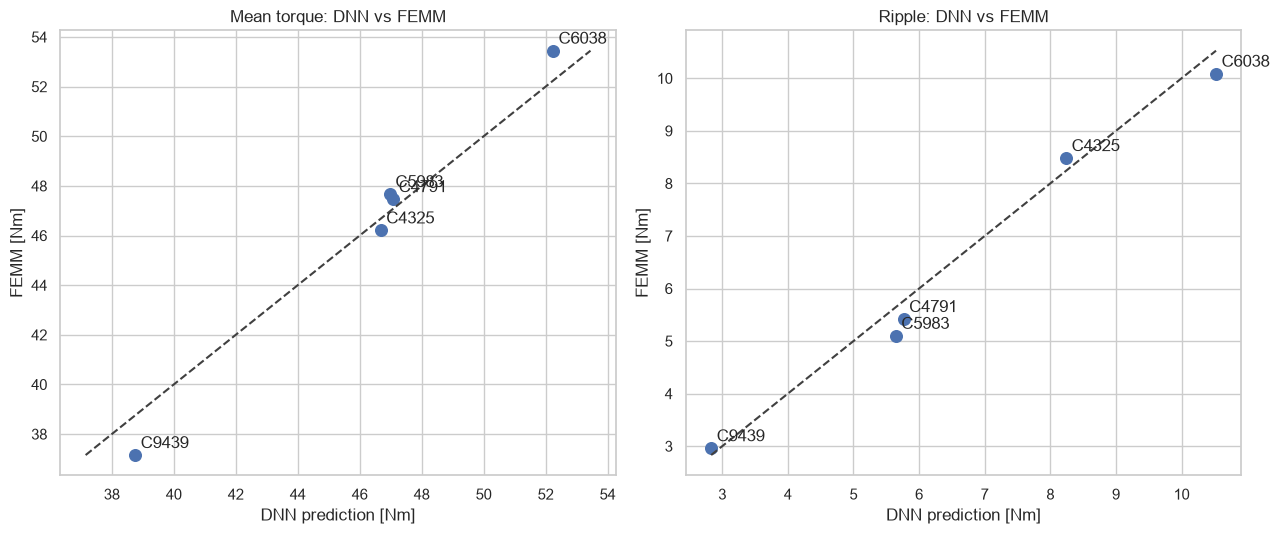

In [14]:
validation_metrics = pd.DataFrame({
    "MAE [Nm]": [
        validation_femm.mean_error_Nm.abs().mean(),
        validation_femm.ripple_error_Nm.abs().mean(),
    ],
    "RMSE [Nm]": [
        np.sqrt(np.mean(validation_femm.mean_error_Nm**2)),
        np.sqrt(np.mean(validation_femm.ripple_error_Nm**2)),
    ],
    "Maximum absolute error [Nm]": [
        validation_femm.mean_error_Nm.abs().max(),
        validation_femm.ripple_error_Nm.abs().max(),
    ],
}, index=["Mean torque", "Ripple pk-pk"])
display(validation_metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pred_col, femm_col, title in [
    (
        axes[0], "pred_mean_torque_Nm", "loaded_torque_mean_Nm",
        "Mean torque: DNN vs FEMM",
    ),
    (
        axes[1], "pred_ripple_pkpk_Nm", "loaded_torque_pkpk_Nm",
        "Ripple: DNN vs FEMM",
    ),
]:
    ax.scatter(
        validation_femm[pred_col], validation_femm[femm_col],
        s=70,
    )
    for _, row in validation_femm.iterrows():
        ax.annotate(
            f"C{int(row.candidate)}",
            (row[pred_col], row[femm_col]),
            xytext=(4, 5), textcoords="offset points",
        )
    lo = min(validation_femm[pred_col].min(), validation_femm[femm_col].min())
    hi = max(validation_femm[pred_col].max(), validation_femm[femm_col].max())
    ax.plot([lo, hi], [lo, hi], "--", color="0.25")
    ax.set(xlabel="DNN prediction [Nm]", ylabel="FEMM [Nm]", title=title)
plt.tight_layout()
plt.show()

## 14.2 실제 토크 파형

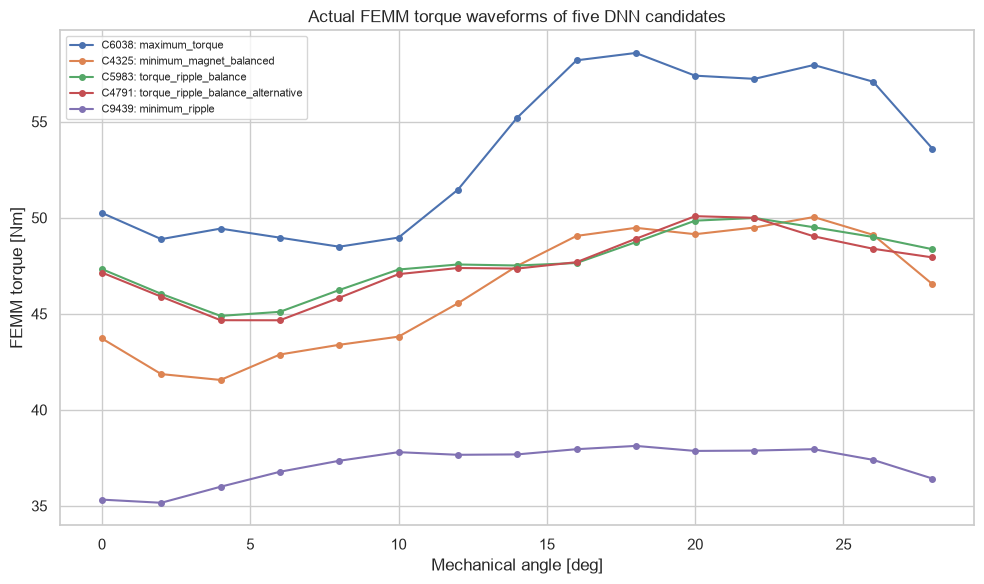

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in validation_femm.iterrows():
    run = int(row.run)
    candidate = int(row.candidate)
    sweep = pd.read_csv(
        VALIDATION_DIR / f"run_{run:03d}"
        / "axis_shortedge_loaded_sweep.csv"
    )
    ax.plot(
        sweep.theta_deg, sweep.torque_Nm,
        "-o", ms=4, label=f"C{candidate}: {row.selection_purpose}",
    )
ax.set(
    xlabel="Mechanical angle [deg]",
    ylabel="FEMM torque [Nm]",
    title="Actual FEMM torque waveforms of five DNN candidates",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 14.3 싱글레이어 기준점과 실제 FEMM 비교

,magnet_volume_total_cm3,mean_torque_Nm,ripple_pkpk_Nm,torque_per_magnet_Nm_cm3
design,,,,
Single Run 14,55.3993,38.6614,3.0458,0.6979
Single Run 27,99.2579,51.0658,10.5968,0.5145
Single Run 42,83.1734,47.9405,5.1456,0.5764
Single Run 49,92.7721,46.7562,4.6941,0.5040
Double C6038,90.1294,53.4481,10.0871,0.5930
Double C4325,58.9821,46.2071,8.4823,0.7834
Double C5983,88.4884,47.6713,5.0995,0.5387
Double C4791,87.0364,47.4692,5.4197,0.5454
Double C9439,58.8335,37.1545,2.9609,0.6315


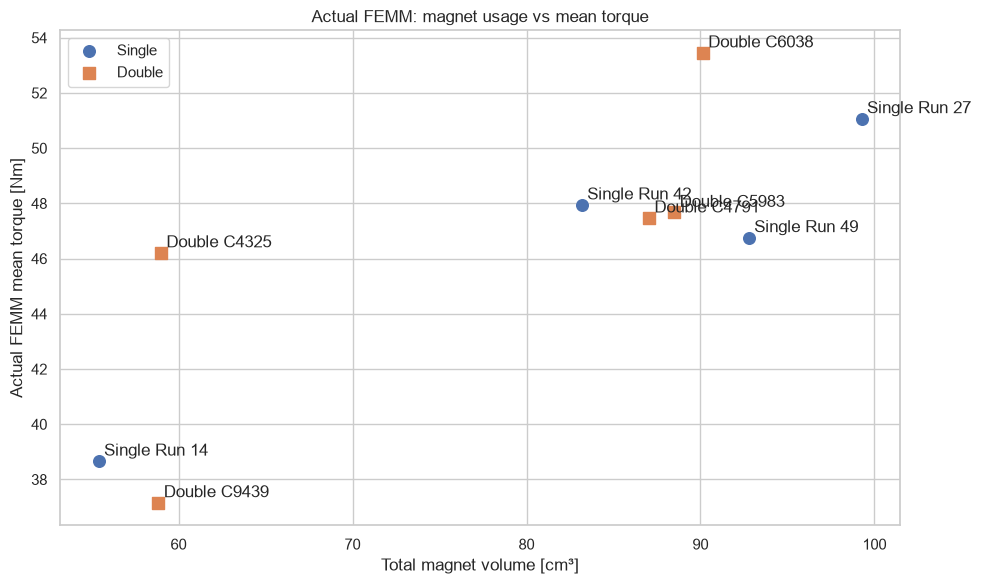

In [16]:
single_reference = single50[single50.run.isin([14, 49, 42, 27])].copy()
single_reference["design"] = "Single Run " + single_reference.run.astype(str)
single_reference["magnet_volume_total_cm3"] = (
    8
    * single_reference.magnet_thickness_mm
    * single_reference.magnet_length_mm
    * motor_base.DEPTH / 1000
)
single_compare = single_reference[[
    "design", "magnet_volume_total_cm3",
    mean_col, ripple_col,
]].rename(columns={
    mean_col: "mean_torque_Nm",
    ripple_col: "ripple_pkpk_Nm",
})

double_compare = validation_femm.copy()
double_compare["design"] = (
    "Double C" + double_compare.candidate.astype(int).astype(str)
)
double_compare = double_compare[[
    "design", "magnet_volume_total_cm3",
    "loaded_torque_mean_Nm", "loaded_torque_pkpk_Nm",
]].rename(columns={
    "loaded_torque_mean_Nm": "mean_torque_Nm",
    "loaded_torque_pkpk_Nm": "ripple_pkpk_Nm",
})
actual_comparison = pd.concat(
    [single_compare, double_compare], ignore_index=True
)
actual_comparison["torque_per_magnet_Nm_cm3"] = (
    actual_comparison.mean_torque_Nm
    / actual_comparison.magnet_volume_total_cm3
)
display(actual_comparison.set_index("design"))

fig, ax = plt.subplots(figsize=(10, 6))
for layer, marker in [("Single", "o"), ("Double", "s")]:
    part = actual_comparison[
        actual_comparison.design.str.startswith(layer)
    ]
    ax.scatter(
        part.magnet_volume_total_cm3,
        part.mean_torque_Nm,
        s=70, marker=marker, label=layer,
    )
    for _, row in part.iterrows():
        ax.annotate(
            row.design,
            (row.magnet_volume_total_cm3, row.mean_torque_Nm),
            xytext=(4, 4), textcoords="offset points",
        )
ax.set(
    xlabel="Total magnet volume [cm³]",
    ylabel="Actual FEMM mean torque [Nm]",
    title="Actual FEMM: magnet usage vs mean torque",
)
ax.legend()
plt.tight_layout()
plt.show()

## 14.4 최종 평가

### Candidate 6038 — 더블레이어 최대토크 우위 확인

- FEMM 평균토크: **53.45 Nm**
- FEMM 리플: **10.09 Nm**
- 자석 체적: **90.13 cm³**
- 싱글레이어 최대 Run 27보다 자석을 약 9% 적게 사용하면서 평균토크는 약 4.7% 높고 리플은 약간 작다.
- 현재 검증점 중 더블레이어의 가장 명확한 성능 우위다.

### Candidate 4325 — 자석 절감 효과 확인

- FEMM 평균토크: **46.21 Nm**
- FEMM 리플: **8.48 Nm**
- 자석 체적: **58.98 cm³**
- 싱글레이어 Run 49와 비슷한 평균토크를 자석 약 36% 절감으로 달성했지만 리플이 약 81% 크다.
- 자석비용 최소화가 중요할 때 유효하고 저리플 설계로는 부적합하다.

### Candidate 5983 — 가장 좋은 실용 균형점

- FEMM 평균토크: **47.67 Nm**
- FEMM 리플: **5.10 Nm**
- 자석 체적: **88.49 cm³**
- 싱글레이어 Run 42보다 평균토크는 약 0.6% 낮고 리플은 약 0.9% 작다.
- 싱글레이어 Run 49보다는 자석을 약 4.6% 줄이고 평균토크를 약 2.0% 높이지만 리플은 약 8.6% 크다.
- 토크·리플·자석량을 함께 볼 때 현재 더블레이어의 가장 실용적인 후보로 판단한다.

### Candidate 4791 — Candidate 5983에 근접

- FEMM 평균토크: **47.47 Nm**
- FEMM 리플: **5.42 Nm**
- 자석 체적: **87.04 cm³**
- Candidate 5983보다 자석은 약 1.6% 적지만 토크와 리플이 모두 조금 불리하다.

### Candidate 9439 — 저리플 우위 미확인

- FEMM 평균토크: **37.15 Nm**
- FEMM 리플: **2.96 Nm**
- 자석 체적: **58.83 cm³**
- 싱글레이어 저리플 Run 14보다 리플은 조금 작지만 토크가 약 3.9% 낮고 자석은 약 6% 많다.
- 저리플 영역에서는 더블레이어의 명확한 이점이 없다.

## 다음 정밀검증 권장

Candidate **6038, 5983, 4325** 세 개를 남긴다.

1. 0–30° / 0.5° 간격 토크 스윕
2. commutation offset 30–40° 재탐색
3. 코깅토크와 무부하 역기전력 THD
4. 최대 반경력 및 브리지 포화 확인

Candidate 4791과 9439는 현재 결과에서는 추가 정밀해석 우선순위가 낮다.